In [5]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import pysoupx

# Configure Scanpy plot settings (updated syntax)
sc.settings.verbosity = 2  # Show detailed progress logs
sc.set_figure_params(dpi=100, facecolor='white', frameon=False)

In [6]:
# 1. Define folder containing your GEO .h5 files
folder = "GSE309604_RAW/"

# 2. Map exact biological replicate filenames
replicates = {
    '5mo_rep1': 'GSM9270315_GFP_5mo_1.h5',
    '5mo_rep2': 'GSM9270316_GFP_5mo_2.h5',
    '9mo_rep1': 'GSM9270321_GFP_9mo_1.h5',
    '9mo_rep2': 'GSM9270322_GFP_9mo_2.h5'
}

# 3. Verify all 4 files exist before proceeding
print("=== VERIFYING REPLICATE FILE PATHS ===")
for label, fname in replicates.items():
    full_path = os.path.join(folder, fname)
    exists = os.path.exists(full_path)
    status = "✅ Found" if exists else "❌ MISSING"
    print(f"{status} | {label}: {fname}")

=== VERIFYING REPLICATE FILE PATHS ===
✅ Found | 5mo_rep1: GSM9270315_GFP_5mo_1.h5
✅ Found | 5mo_rep2: GSM9270316_GFP_5mo_2.h5
✅ Found | 9mo_rep1: GSM9270321_GFP_9mo_1.h5
✅ Found | 9mo_rep2: GSM9270322_GFP_9mo_2.h5


In [7]:
import scanpy as sc
import pydecontx
import os

folder = "GSE309604_RAW/"
replicates = {
    '5mo_rep1': 'GSM9270315_GFP_5mo_1.h5',
    '5mo_rep2': 'GSM9270316_GFP_5mo_2.h5',
    '9mo_rep1': 'GSM9270321_GFP_9mo_1.h5',
    '9mo_rep2': 'GSM9270322_GFP_9mo_2.h5'
}

cleaned_adatas = []

for label, fname in replicates.items():
    path = os.path.join(folder, fname)
    print(f"\n🧼 Running DecontX Decontamination on {label} ({fname})...")
    
    # 1. Read pre-filtered matrix
    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()
    adata.obs_names_make_unique()
    
    # 2. Quick pre-clustering (required for DecontX)
    adata_prep = adata.copy()
    sc.pp.normalize_total(adata_prep, target_sum=1e4)
    sc.pp.log1p(adata_prep)
    sc.pp.highly_variable_genes(adata_prep, n_top_genes=2000)
    sc.pp.pca(adata_prep, mask_var="highly_variable")
    sc.pp.neighbors(adata_prep)
    sc.tl.leiden(adata_prep, key_added='decont_cluster')
    
    # Store cluster assignments
    adata.obs['decont_cluster'] = adata_prep.obs['decont_cluster']
    
    # 3. Estimate & remove ambient background using DecontX
    res = pydecontx.decontx(adata, z='decont_cluster')
    
    # 4. Extract results & transpose matrix (.T) to match AnnData shape (cells x genes)
    adata.layers['raw_counts'] = adata.X.copy()
    adata.layers['decontX_counts'] = res.decontx_counts.T
    adata.X = res.decontx_counts.T.copy()
    adata.obs['contamination'] = res.contamination
    
    # Report mean contamination fraction
    mean_contam = adata.obs['contamination'].mean()
    print(f"   Estimated Mean Contamination for {label}: {mean_contam:.2%}")
    
    # Assign metadata labels
    adata.obs['replicate'] = label
    adata.obs['age'] = '5mo' if '5mo' in label else '9mo'
    
    cleaned_adatas.append(adata)

# Concatenate all 4 decontaminated replicate datasets
adata = sc.concat(cleaned_adatas, join="outer")
adata.obs_names_make_unique()

print(f"\n✅ Success! All 4 replicates decontaminated with DecontX.")
print(f"Combined Object: {adata.n_obs} cells across {adata.n_vars} genes")


🧼 Running DecontX Decontamination on 5mo_rep1 (GSM9270315_GFP_5mo_1.h5)...
reading GSE309604_RAW/GSM9270315_GFP_5mo_1.h5
 (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes


/Users/tylerparks/Desktop/rise-research/sca/lib/python3.12/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:00)
running Leiden clustering


/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_8847/2920261594.py:31: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_prep, key_added='decont_cluster')


    finished (0:00:03)
   Estimated Mean Contamination for 5mo_rep1: 7.46%

🧼 Running DecontX Decontamination on 5mo_rep2 (GSM9270316_GFP_5mo_2.h5)...
reading GSE309604_RAW/GSM9270316_GFP_5mo_2.h5
 (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes


...

/Users/tylerparks/Desktop/rise-research/sca/lib/python3.12/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:00)
running Leiden clustering


/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_8847/2920261594.py:31: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_prep, key_added='decont_cluster')


    finished (0:00:15)
   Estimated Mean Contamination for 9mo_rep2: 8.70%

✅ Success! All 4 replicates decontaminated with DecontX.
Combined Object: 83913 cells across 21835 genes


/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_8847/2920261594.py:56: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata = sc.concat(cleaned_adatas, join="outer")


In [8]:
# Ensure cell barcodes are unique across concatenated replicates
adata.obs_names_make_unique()
print(f"✅ Barcodes fixed! Object contains {adata.n_obs} unique cells.")

✅ Barcodes fixed! Object contains 83913 unique cells.


✅ QC metrics calculated!


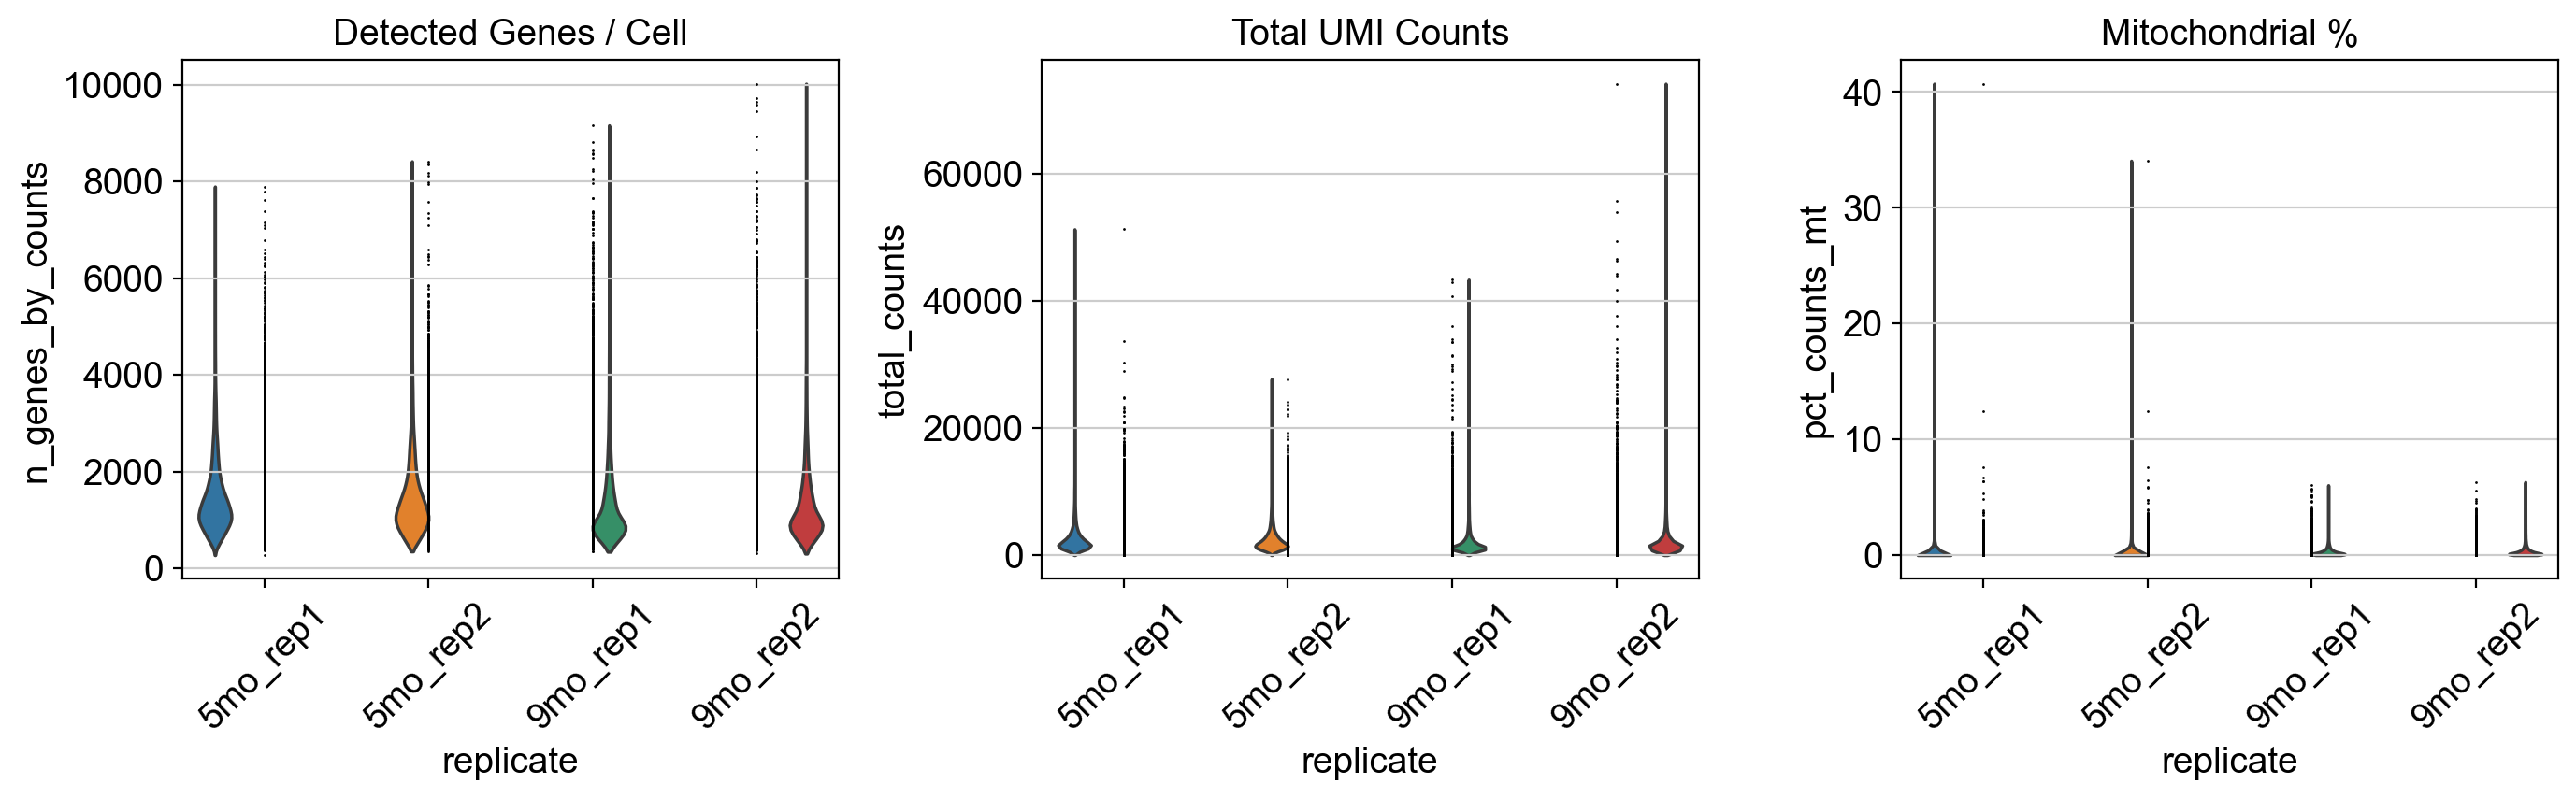

In [9]:
import scanpy as sc
import matplotlib.pyplot as plt

import scanpy as sc

# 1. Identify mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('mt-') | adata.var_names.str.startswith('MT-')

# 2. Calculate QC metrics (this populates 'n_genes_by_counts', 'total_counts', and 'pct_counts_mt' in adata.obs)
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print("✅ QC metrics calculated!")

# Set clean matplotlib defaults
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True)

# 1. n_genes_by_counts
sc.pl.violin(
    adata, 
    'n_genes_by_counts', 
    groupby='replicate', 
    jitter=0, 
    ax=axes[0], 
    show=False
)
axes[0].set_title('Detected Genes / Cell')
axes[0].tick_params(axis='x', rotation=45)

# 2. total_counts
sc.pl.violin(
    adata, 
    'total_counts', 
    groupby='replicate', 
    jitter=0, 
    ax=axes[1], 
    show=False
)
axes[1].set_title('Total UMI Counts')
axes[1].tick_params(axis='x', rotation=45)

# 3. pct_counts_mt
sc.pl.violin(
    adata, 
    'pct_counts_mt', 
    groupby='replicate', 
    jitter=0, 
    ax=axes[2], 
    show=False
)
axes[2].set_title('Mitochondrial %')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

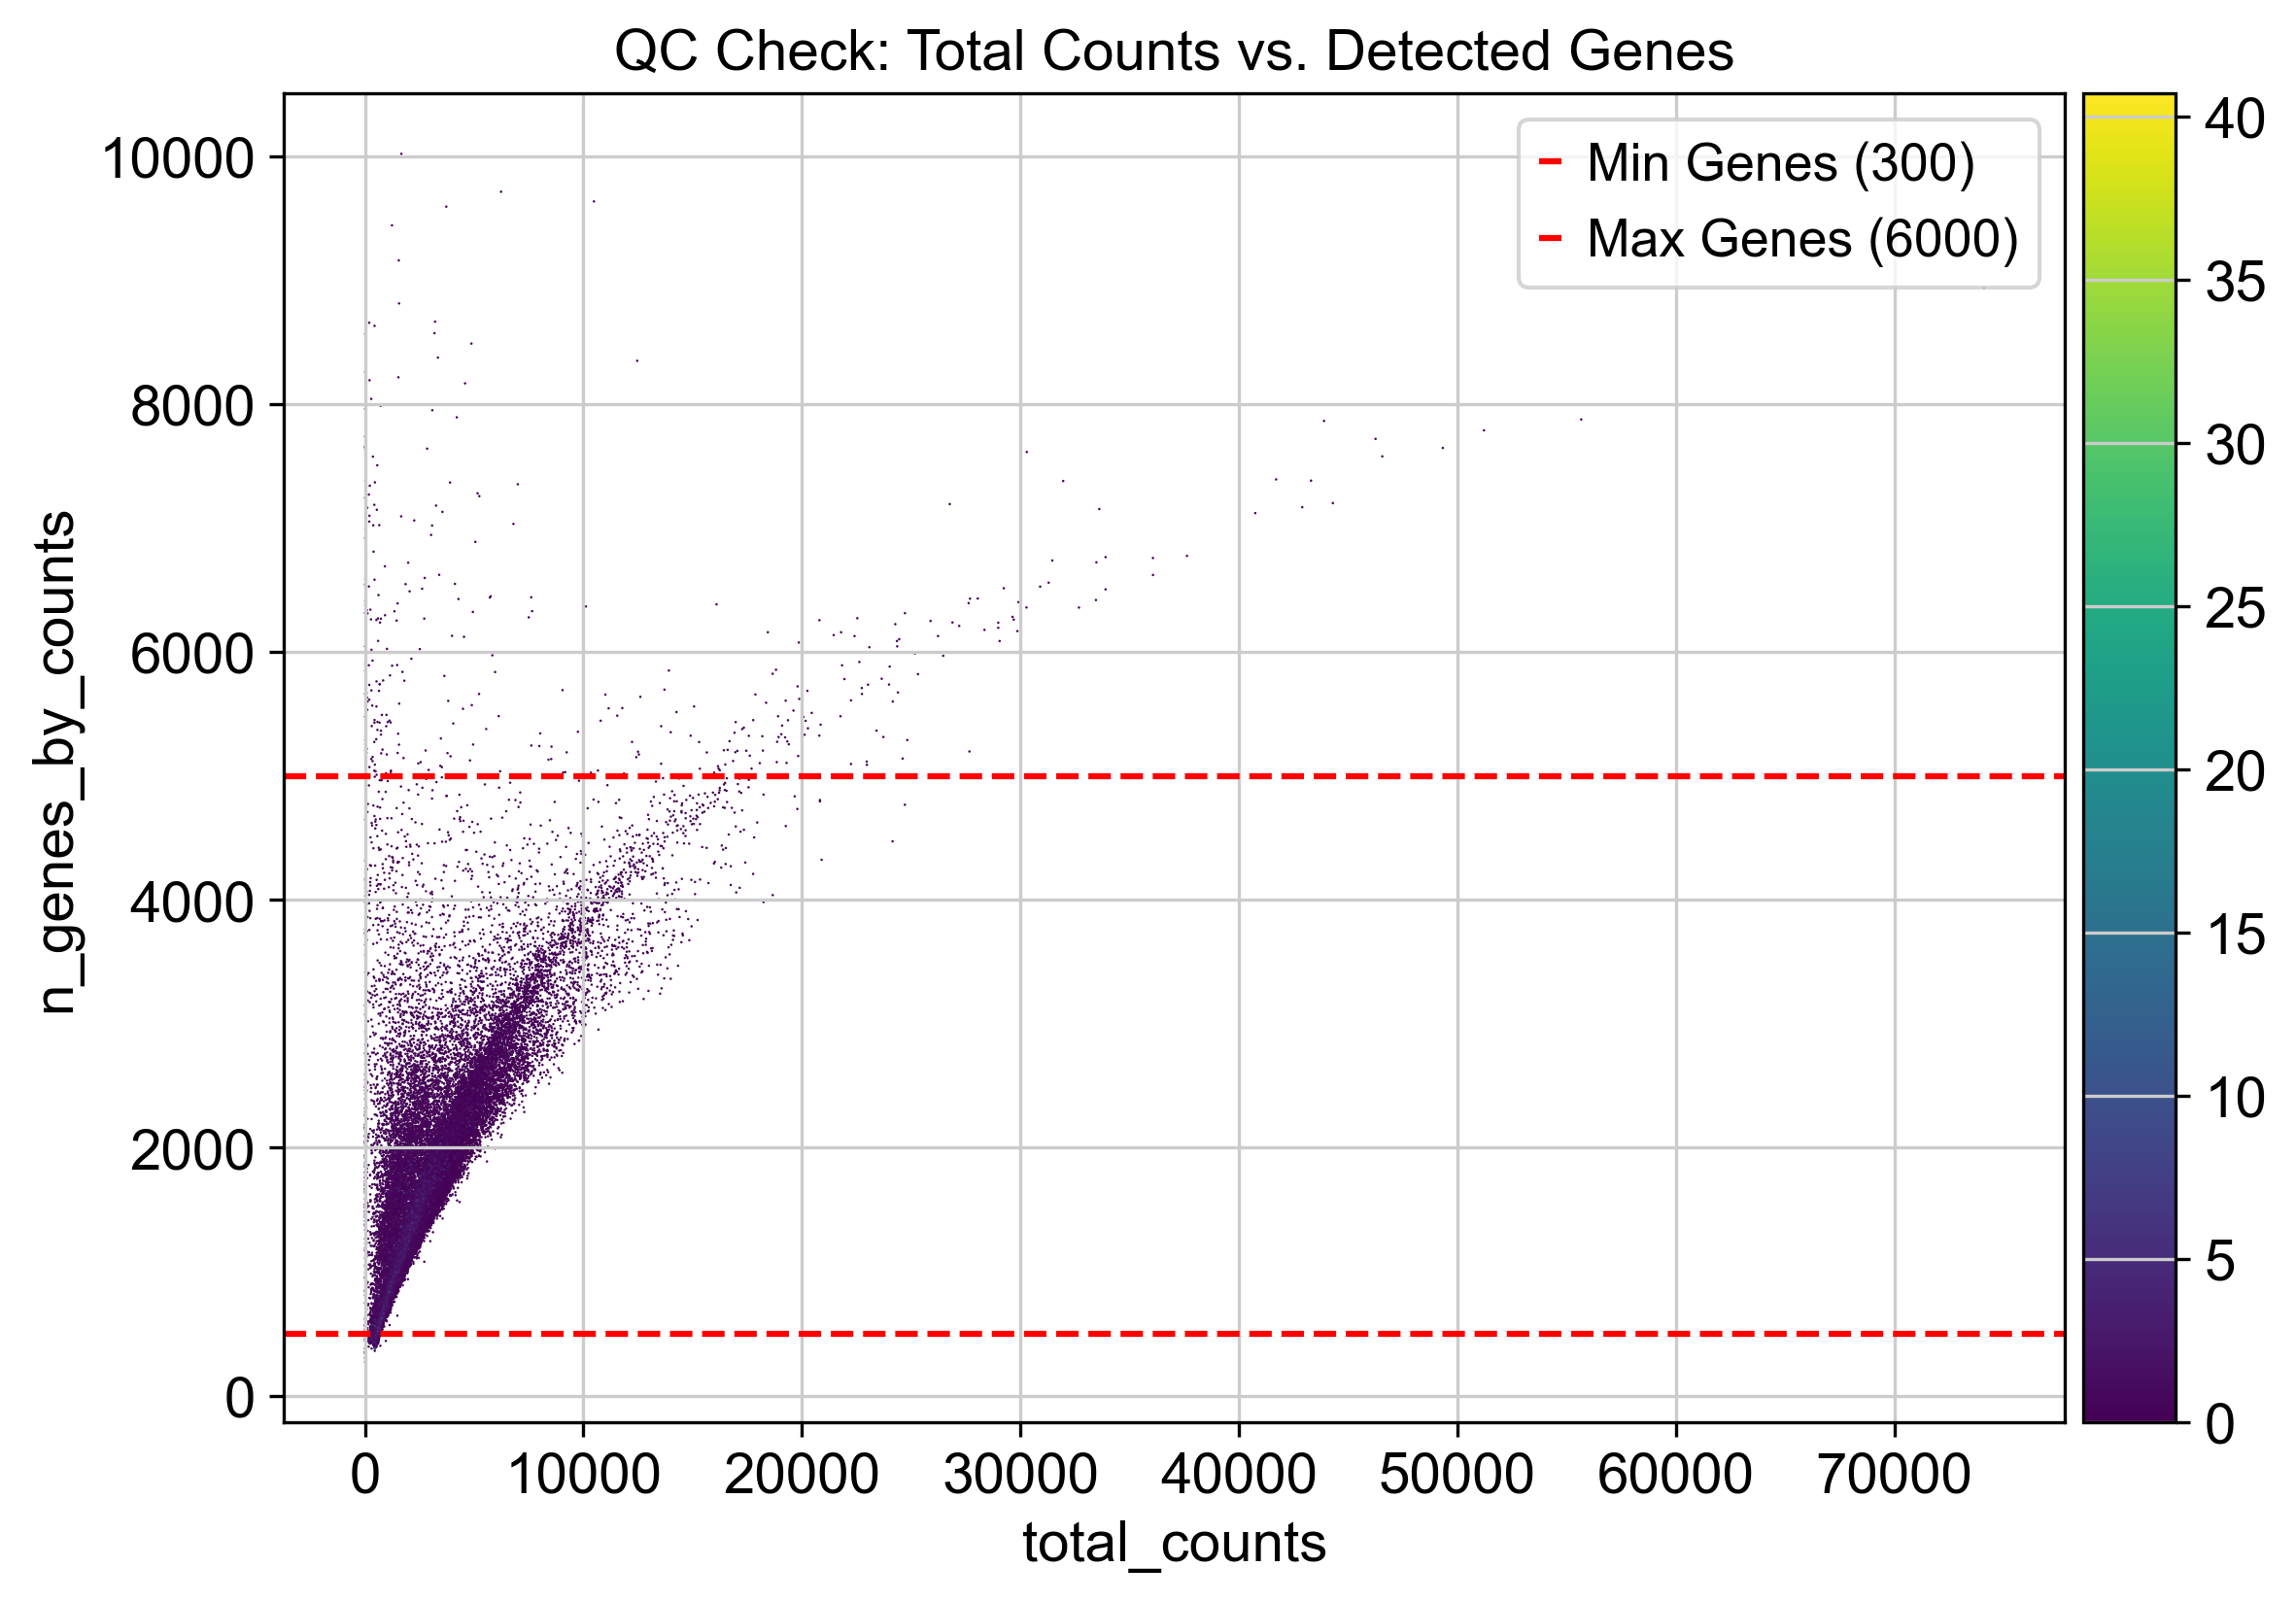

In [10]:
import scanpy as sc

# Set high DPI and large figure size globally for Scanpy plots
sc.set_figure_params(dpi=150, figsize=(7, 6), frameon=True, facecolor='white')

# Generate the joint QC scatter plot
ax = sc.pl.scatter(
    adata, 
    x='total_counts', 
    y='n_genes_by_counts', 
    color='pct_counts_mt',
    title="QC Check: Total Counts vs. Detected Genes",
    show=False
)

# Add reference cutoff lines directly to the plot
ax.axhline(500, color='red', linestyle='--', linewidth=1.5, label='Min Genes (300)')
ax.axhline(5000, color='red', linestyle='--', linewidth=1.5, label='Max Genes (6000)')
ax.legend(loc='upper right')

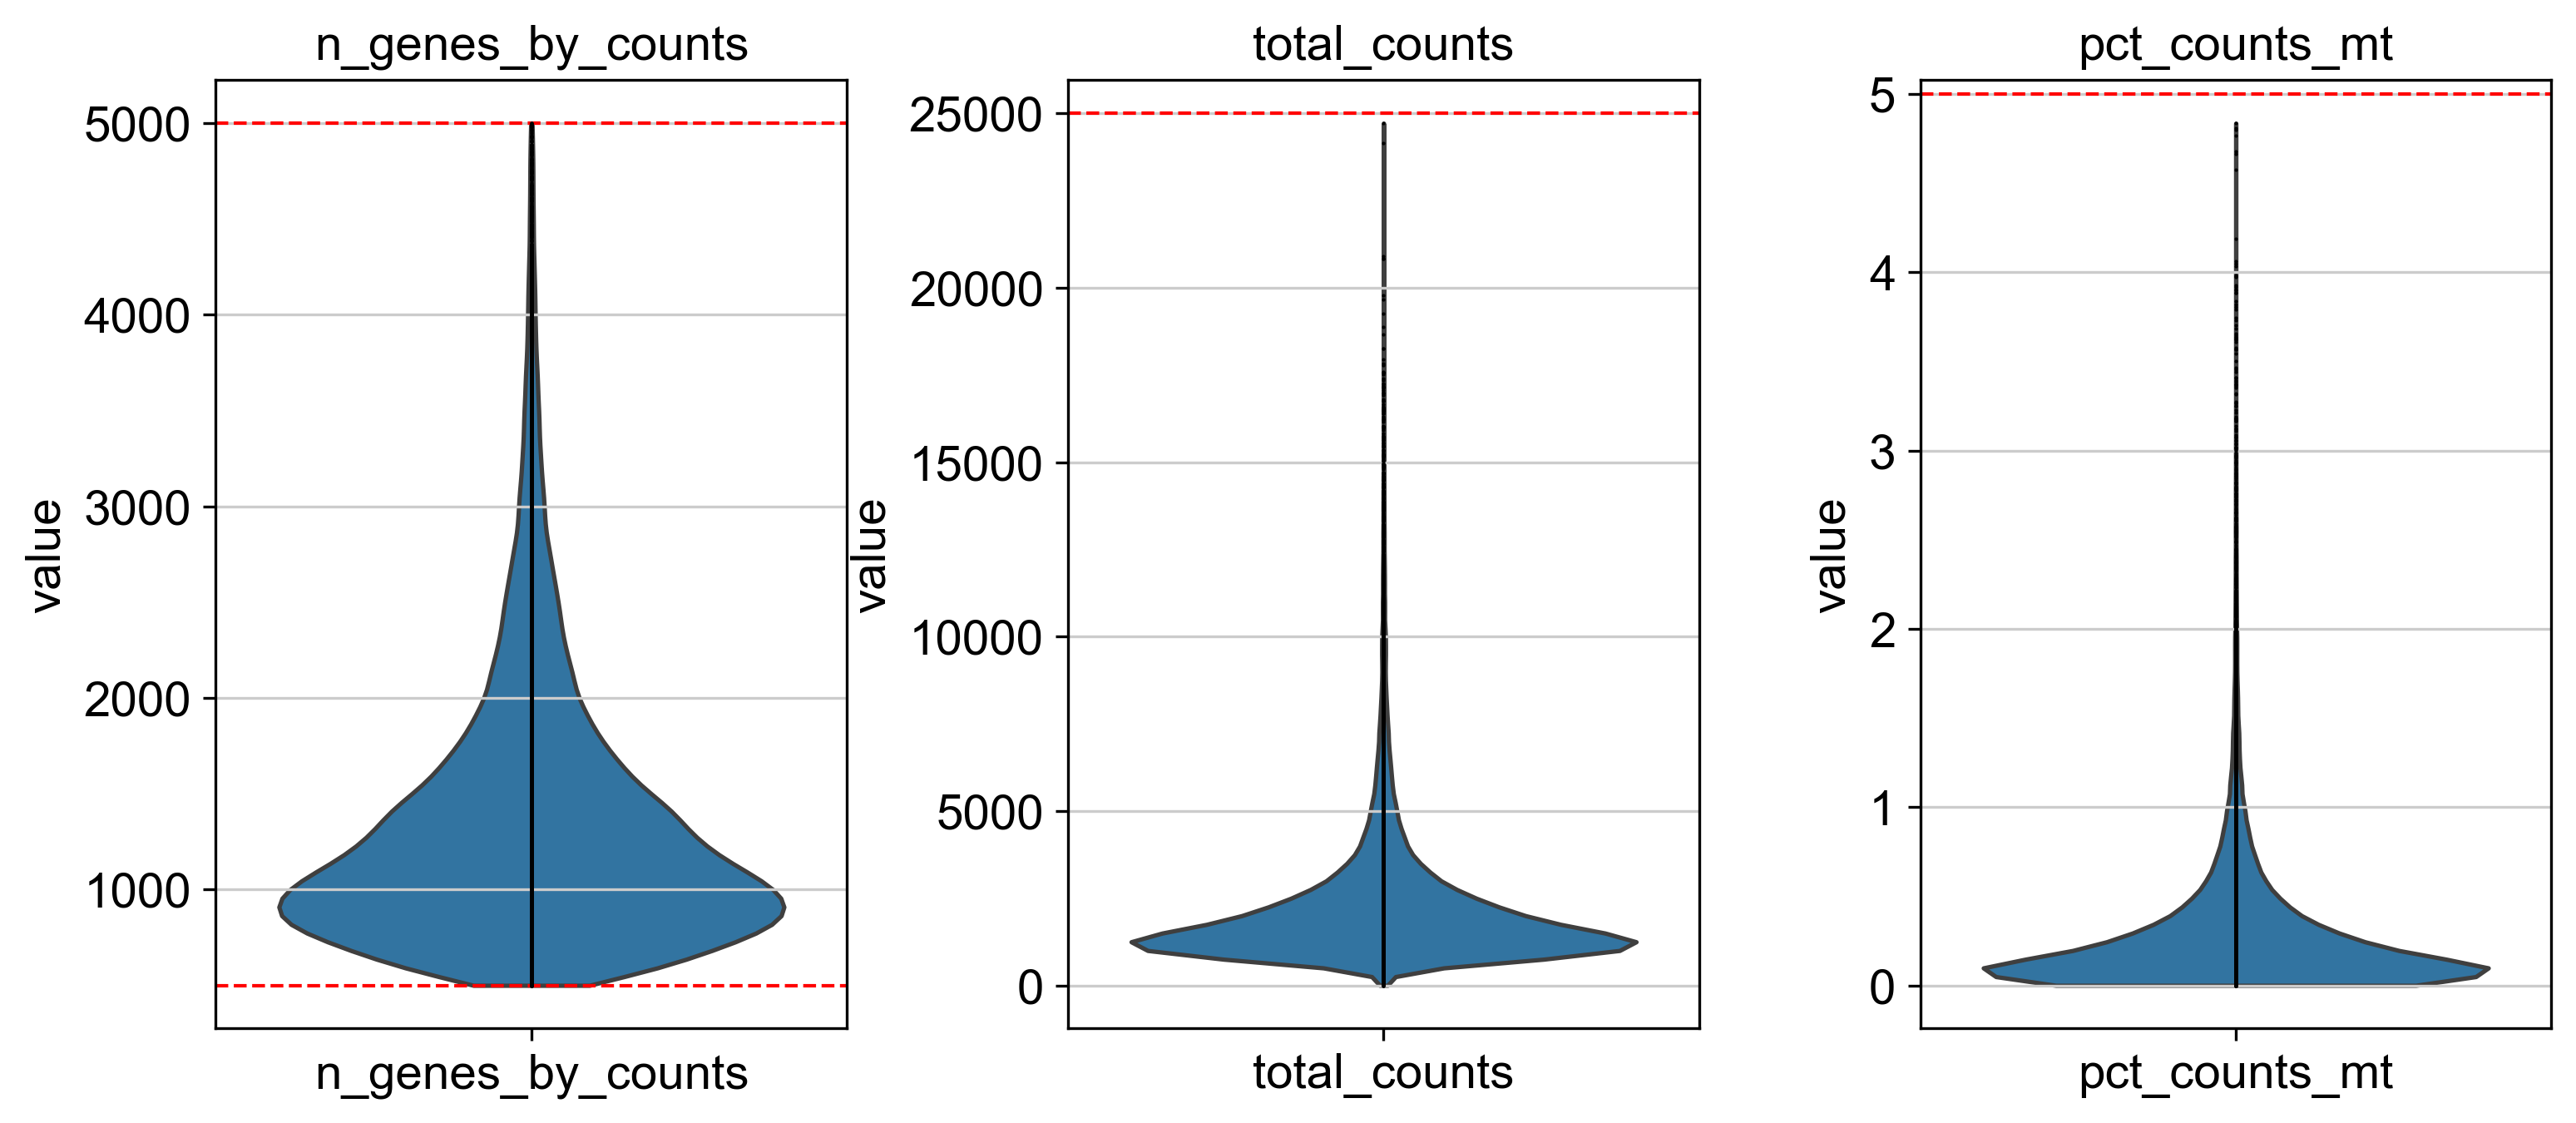

In [5]:
import scanpy as sc
import matplotlib.pyplot as plt

# Set figure parameters for high resolution and clear layout
sc.set_figure_params(dpi=150, figsize=(4, 5), frameon=True, facecolor='white')

# Create a 1x3 grid for the three metrics
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# 1. Detected Genes
sc.pl.violin(
    adata, 
    'n_genes_by_counts', 
    jitter=0, 
    ax=axes[0], 
    show=False
)
axes[0].set_title("n_genes_by_counts")
axes[0].axhline(500, color='red', linestyle='--', linewidth=1)
axes[0].axhline(5000, color='red', linestyle='--', linewidth=1)

# 2. Total Counts
sc.pl.violin(
    adata, 
    'total_counts', 
    jitter=0, 
    ax=axes[1], 
    show=False
)
axes[1].set_title("total_counts")
axes[1].axhline(25000, color='red', linestyle='--', linewidth=1)

# 3. Mitochondrial Percentage
sc.pl.violin(
    adata, 
    'pct_counts_mt', 
    jitter=0, 
    ax=axes[2], 
    show=False
)
axes[2].set_title("pct_counts_mt")
axes[2].axhline(5, color='red', linestyle='--', linewidth=1)

# Adjust layout to prevent overlap
plt.subplots_adjust(wspace=0.35)
plt.show()

In [12]:
import scanpy as sc

print(f"Cells before filtering: {adata.n_obs}")

# 1. Apply authors' exact QC filtering parameters:
# - Unique genes: keep between 500 and 5000
# - Total UMIs: keep <= 25,000
# - Mitochondrial %: keep <= 5%
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_cells(adata, max_genes=5000)
sc.pp.filter_cells(adata, max_counts=25000)
adata = adata[adata.obs['pct_counts_mt'] <= 5.0].copy()

# 2. Filter out non-expressed genes (genes present in < 3 cells)
sc.pp.filter_genes(adata, min_cells=3)

print(f"✅ Cells remaining after paper QC filters: {adata.n_obs}")
print(f"✅ Genes remaining: {adata.n_vars}")

Cells before filtering: 83913
filtered out 1814 cells that have less than 500 genes expressed
filtered out 381 cells that have more than 5000 genes expressed
filtered out 3655 genes that are detected in less than 3 cells
✅ Cells remaining after paper QC filters: 81698
✅ Genes remaining: 18180



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
=== RUNNING DOUBLET DETECTION (SCRUBLET) ===
Running Scrublet
filtered out 965 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.15
Detected doublet rate = 4.9%
Estimated detectable doublet fraction = 62.8%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 7.8%
filtered out 972 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing 

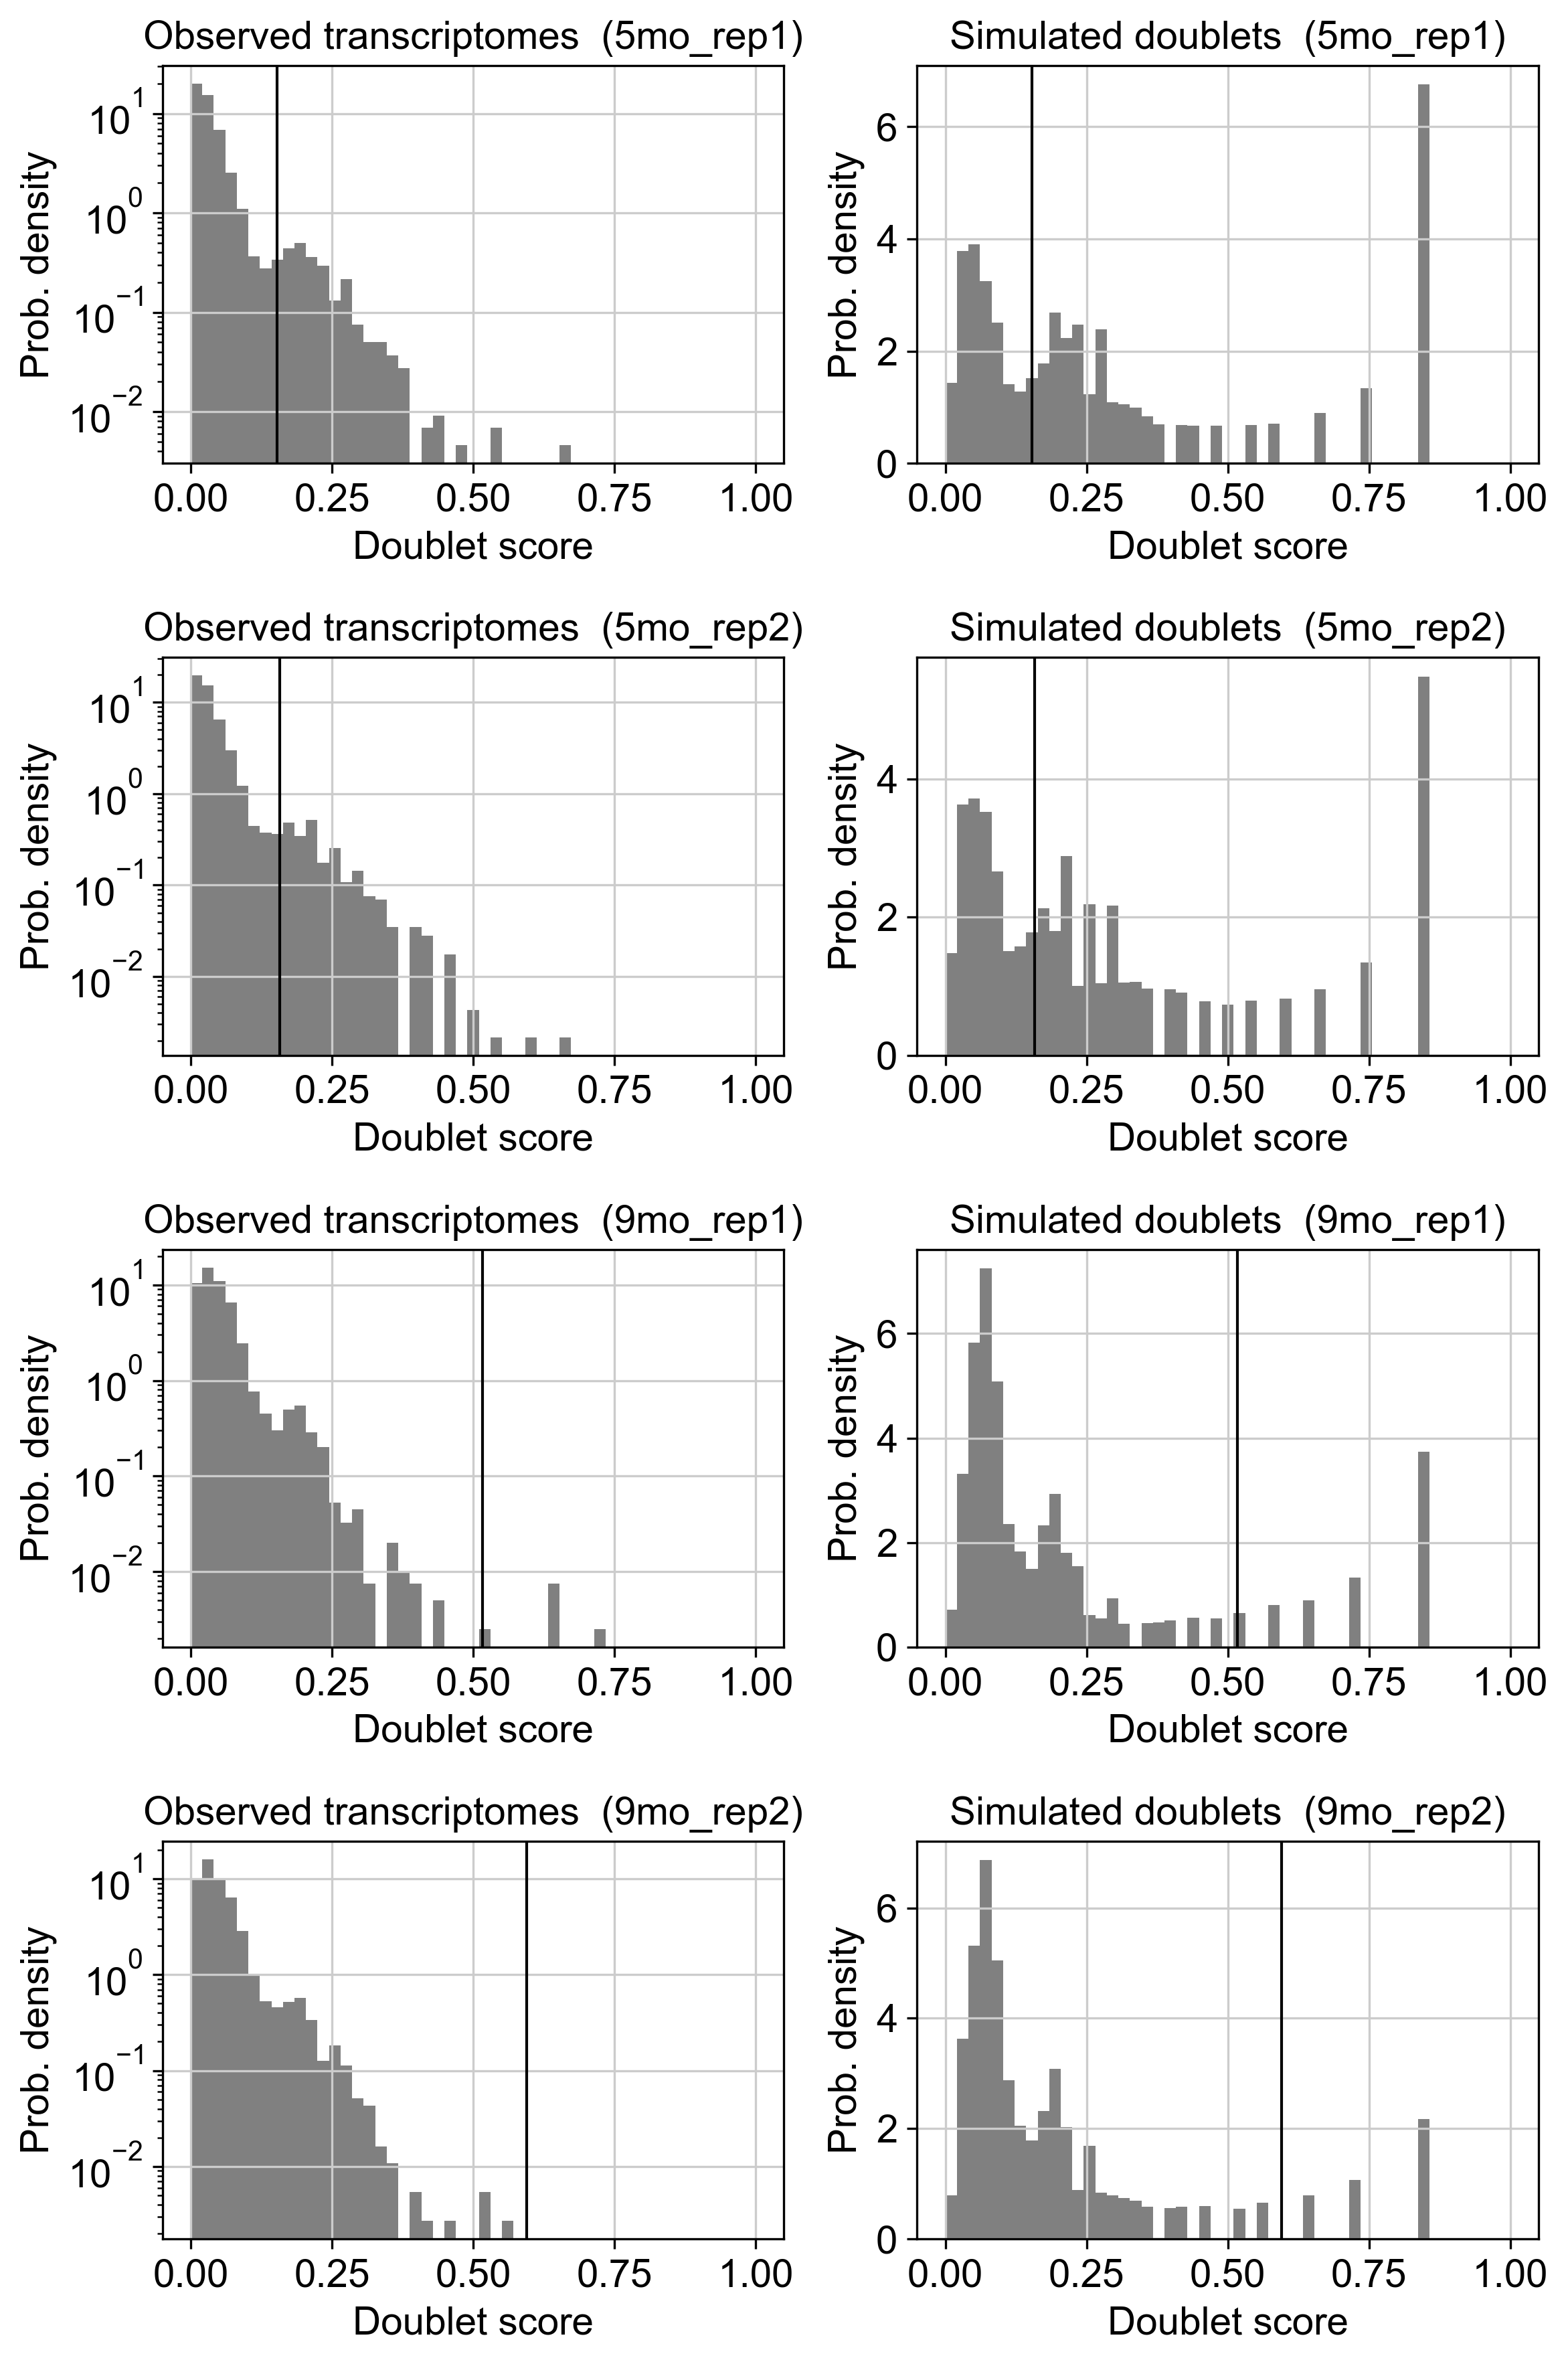

Cells remaining after doublet removal: 79495
✅ Dataset saved successfully!


In [13]:
import scanpy as sc
import matplotlib.pyplot as plt

%pip install scikit-image

print("=== RUNNING DOUBLET DETECTION (SCRUBLET) ===")

# 1. Run Scrublet per sample batch
# Note: 'batch_key' tells Scrublet to simulate doublets independently per replicate
sc.pp.scrublet(adata, batch_key='replicate')

# 2. Inspect Scrublet predicted doublets summary
doublet_counts = adata.obs['predicted_doublet'].value_counts()
print("\n--- Doublet Summary ---")
print(doublet_counts)
print(f"Percentage of detected doublets: {(doublet_counts.get(True, 0) / adata.n_obs) * 100:.2f}%")

# 3. Visualize Scrublet scores across your replicates
sc.pl.scrublet_score_distribution(adata)

# Filter immediately:
adata = adata[~adata.obs['predicted_doublet']].copy()
print(f"Cells remaining after doublet removal: {adata.n_obs}")

# Save your current clean, normalized, PCA-calculated dataset
adata.write("adata_decontX_qc_filtered.h5ad")
print("✅ Dataset saved successfully!")

In [1]:
import scanpy as sc
import pandas as pd

adata = sc.read_h5ad("adata_decontX_qc_filtered.h5ad")

# Define key sex chromosome markers (mouse nomenclature)
female_genes = ['Xist']
male_genes = ['Ddx3y', 'Eif2s3y', 'Uty']

# Filter for genes present in your dataset
female_genes = [g for g in female_genes if g in adata.var_names]
male_genes = [g for g in male_genes if g in adata.var_names]

# Calculate mean expression per replicate
sex_df = pd.DataFrame(index=adata.obs['replicate'].unique())

for g in female_genes + male_genes:
    sex_df[g] = [
        adata[adata.obs['replicate'] == rep, g].X.mean() 
        for rep in sex_df.index
    ]

print("=== Mean Expression of Sex Markers per Replicate ===")
print(sex_df)

=== Mean Expression of Sex Markers per Replicate ===
             Ddx3y   Eif2s3y       Uty
5mo_rep1  0.183763  0.167735  0.622067
5mo_rep2  0.177785  0.156029  0.602834
9mo_rep1  0.166514  0.142986  0.468264
9mo_rep2  0.183595  0.151405  0.493469


In [2]:
# Annotate all replicates as male based on Y-chromosome expression
adata.obs['sex'] = 'Male'

# Confirm annotation in obs
print("=== Sample Sex Annotation ===")
print(adata.obs[['replicate', 'sex']].drop_duplicates())

=== Sample Sex Annotation ===
                   replicate   sex
AAACCTGAGACGCAAC-1  5mo_rep1  Male
AAACCTGAGAACAATC-1  5mo_rep2  Male
AAACCTGAGAACTCGG-1  9mo_rep1  Male
AAACCTGAGAACAACT-1  9mo_rep2  Male


In [3]:
import scanpy as sc

print("=== STEP 6: NORMALIZATION & LOG-TRANSFORMATION ===")

# 1. Save raw integer count matrix into a layer
adata.layers["counts"] = adata.X.copy()

# 2. Normalize cells to median total counts (default target_sum=None uses median)
sc.pp.normalize_total(adata)

# 3. Logarithmize the expression matrix: log(count + 1)
sc.pp.log1p(adata)

print("✅ Normalization and log1p transformation complete!")
print(f"Data layer 'counts' preserved with shape: {adata.layers['counts'].shape}")

=== STEP 6: NORMALIZATION & LOG-TRANSFORMATION ===
✅ Normalization and log1p transformation complete!
Data layer 'counts' preserved with shape: (79495, 18180)


=== FEATURE SELECTION & PCA ===


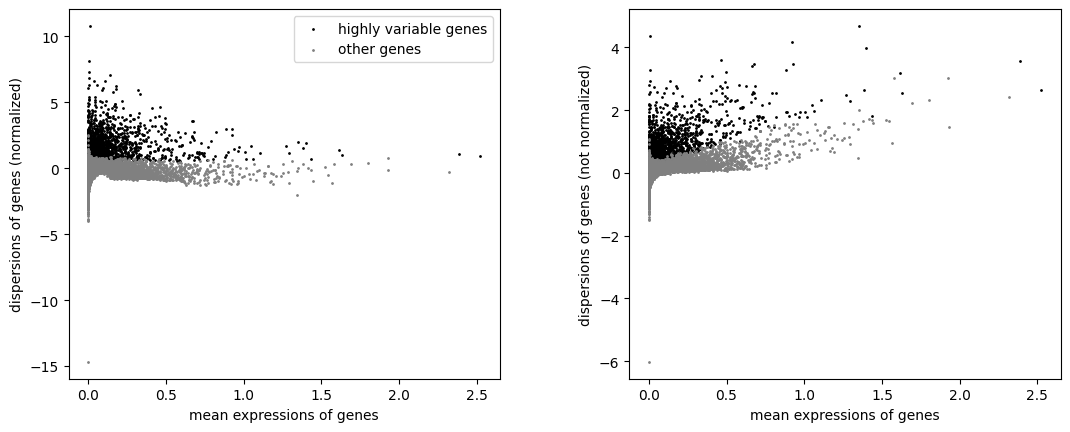

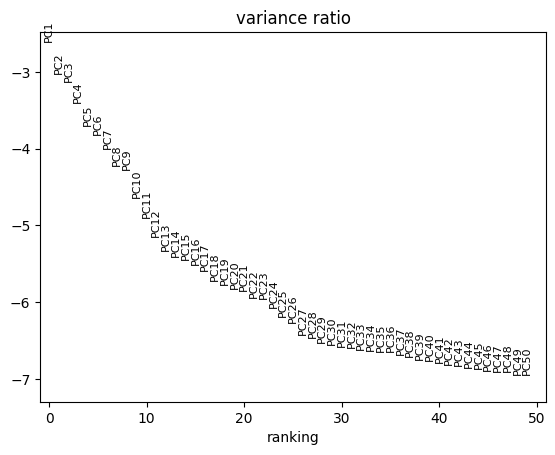

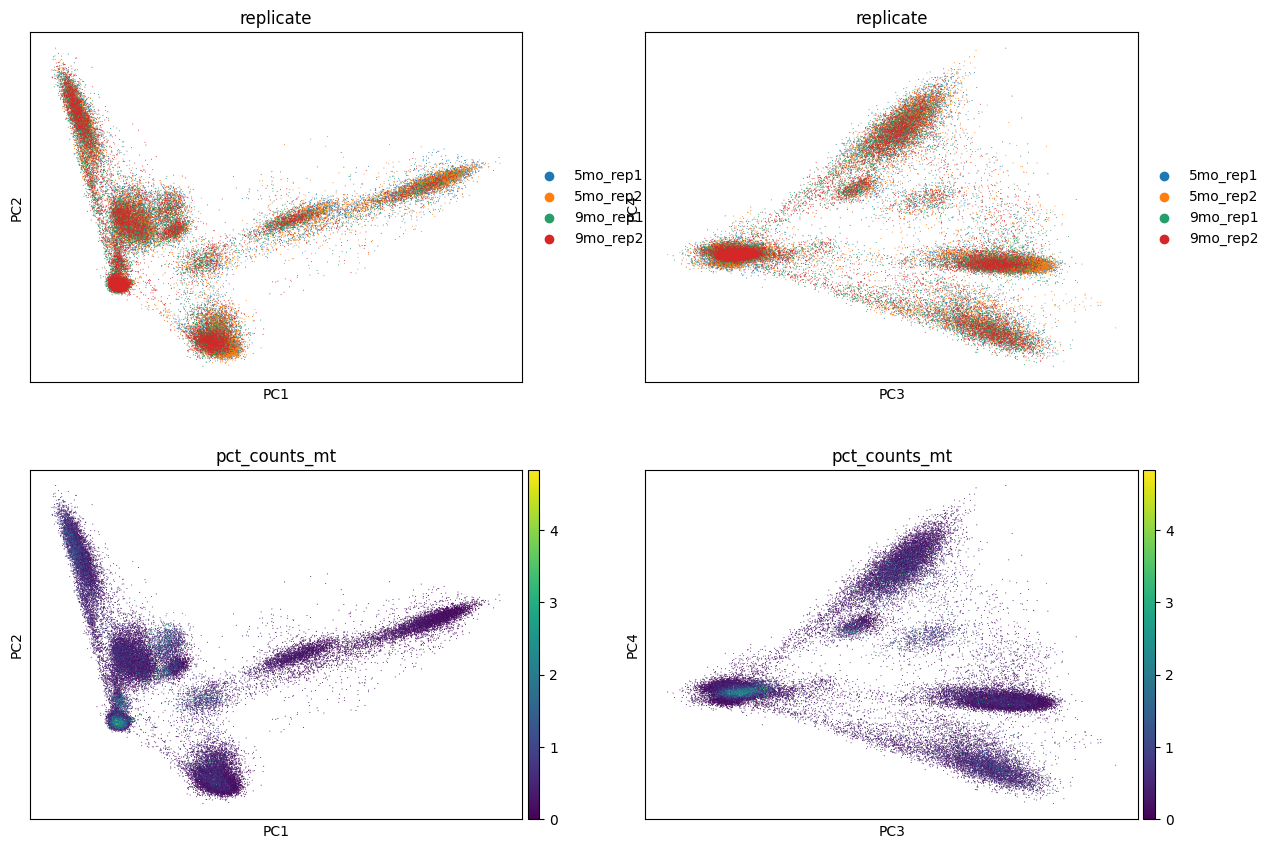

✅ Saved checkpoint: snRNA_post_pca.h5ad


In [4]:
import scanpy as sc

print("=== FEATURE SELECTION & PCA ===")

# 1. Feature Selection (2000 HVGs per sample batch)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='replicate')
sc.pl.highly_variable_genes(adata)

# 2. Freeze full normalized expression matrix into .raw for downstream DEG
adata.raw = adata

# 3. Scale data with zero_center=False BEFORE PCA (prevents RAM densification warning)
sc.pp.scale(adata, max_value=10, zero_center=False)

# 4. Run PCA
sc.tl.pca(adata)

# 5. Elbow Plot (scree plot)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

# 6. Diagnostic PCA Plots
sc.pl.pca(
    adata,
    color=["replicate", "replicate", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

# 7. Save checkpoint
adata.write("snRNA_post_pca.h5ad")
print("✅ Saved checkpoint: snRNA_post_pca.h5ad")

=== 1. NEIGHBORHOOD GRAPH & UMAP ===


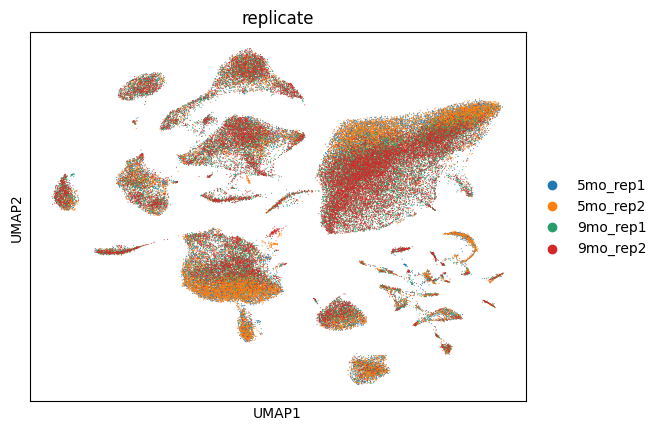

=== 2. LEIDEN CLUSTERING ===


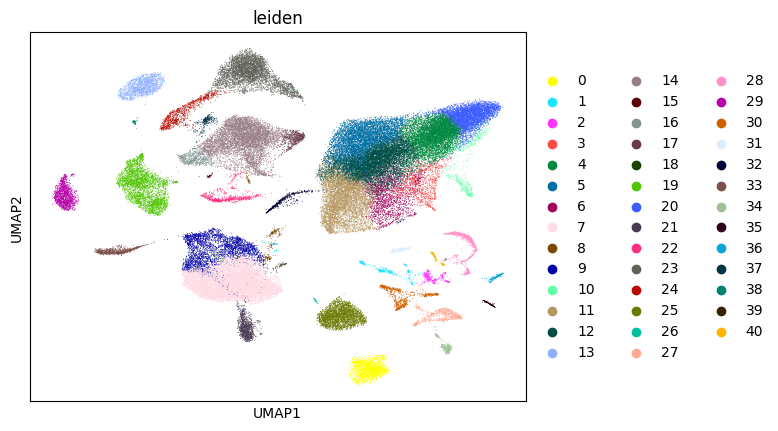

=== 3. RE-ASSESS QC METRICS ON UMAP ===


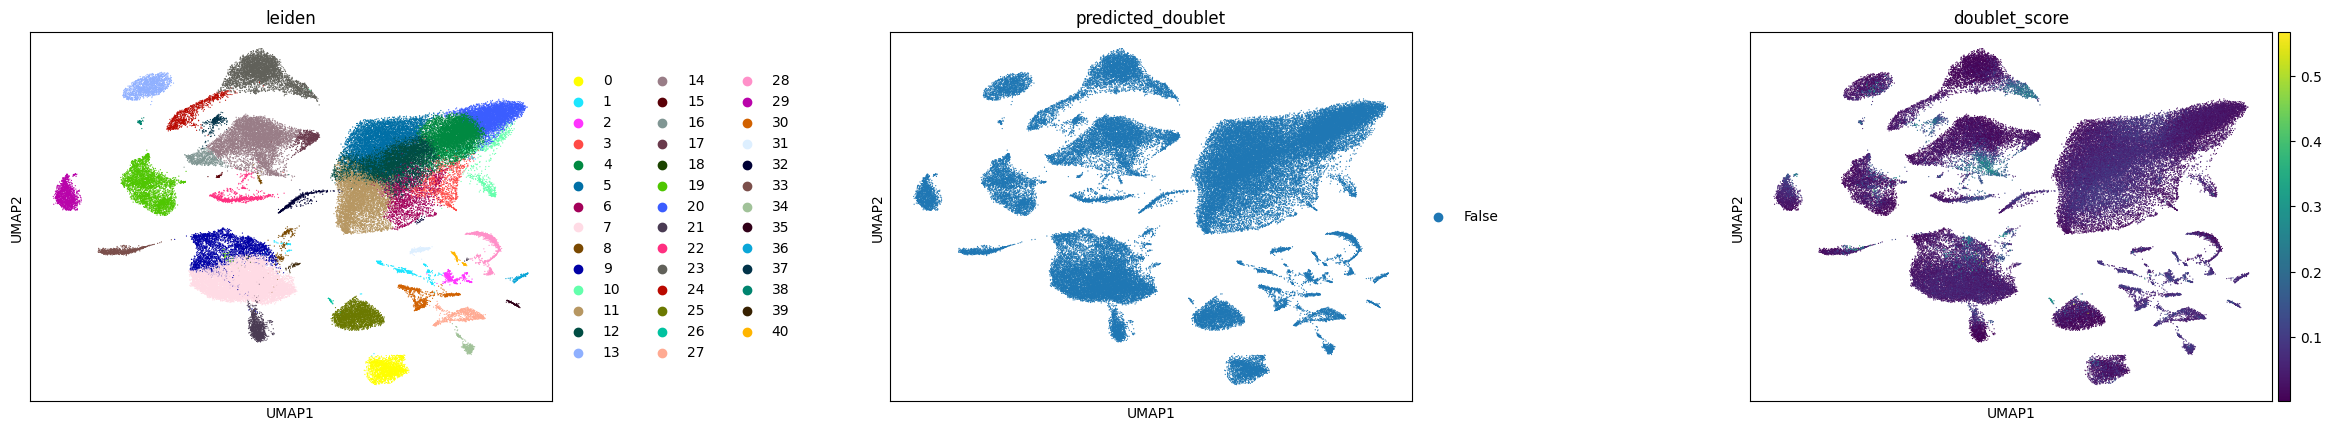

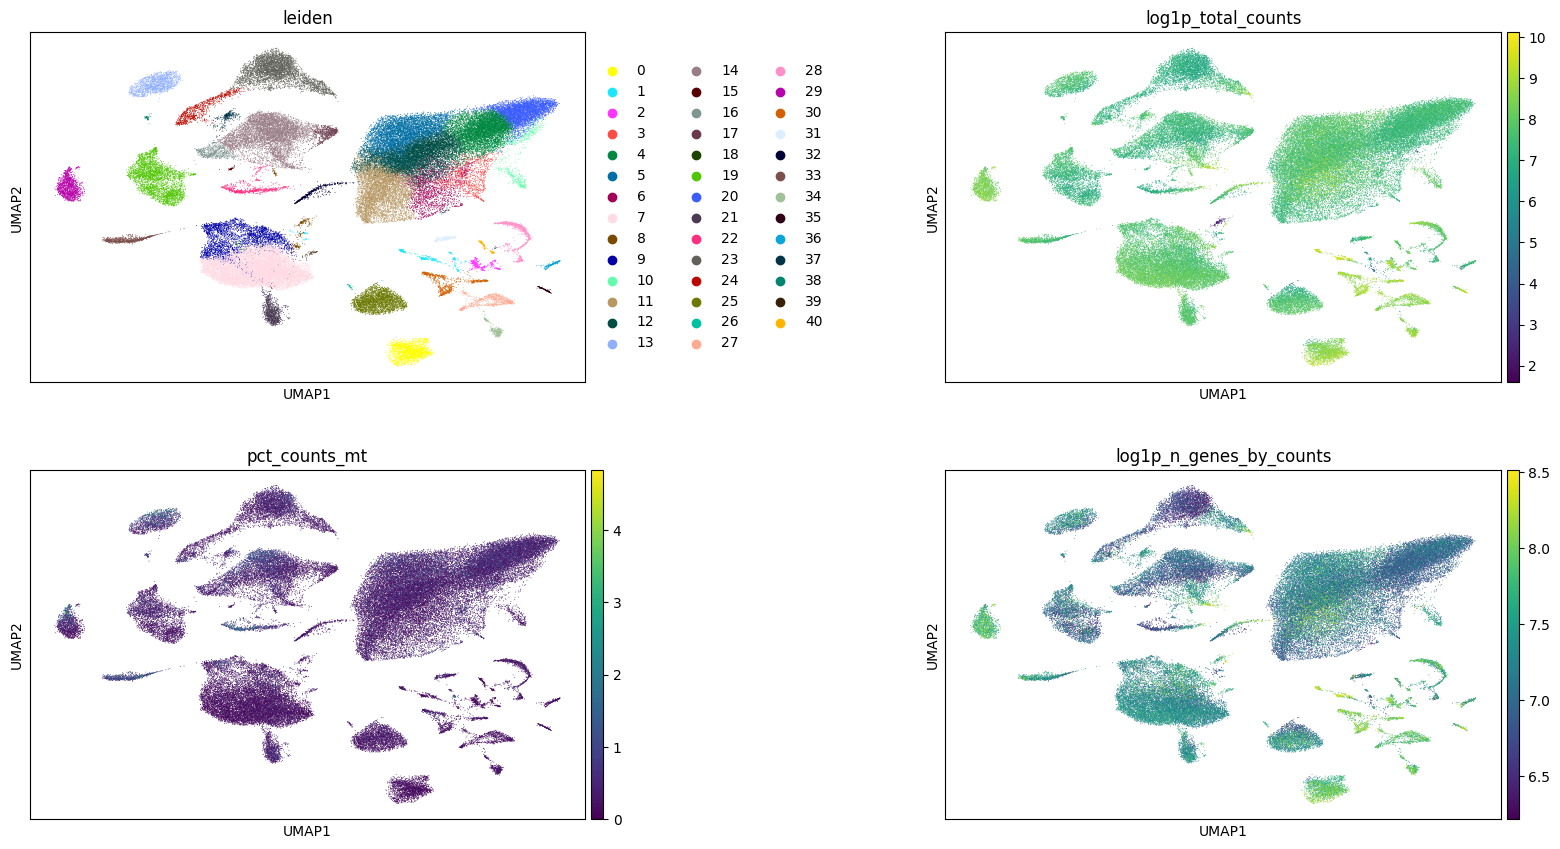

=== 4. SAVE CHECKPOINT ===
✅ Saved checkpoint: snRNA_clustered_umap.h5ad


In [7]:
import scanpy as sc
import numpy as np

adata = sc.read_h5ad("snRNA_post_pca.h5ad")

print("=== 1. NEIGHBORHOOD GRAPH & UMAP ===")
# Compute k-nearest neighbors graph on PCA coordinates
sc.pp.neighbors(adata)

# Embed the graph in 2D space using UMAP
sc.tl.umap(adata)

# Visualize UMAP colored by replicate sample
sc.pl.umap(
    adata,
    color="replicate",
    size=2,
)

print("=== 2. LEIDEN CLUSTERING ===")
# Perform fast Leiden graph-based clustering via igraph
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

# Visualize clusters
sc.pl.umap(adata, color=["leiden"])

print("=== 3. RE-ASSESS QC METRICS ON UMAP ===")
# Calculate log1p metrics in obs to match the tutorial
adata.obs["log1p_total_counts"] = np.log1p(adata.obs["total_counts"])
adata.obs["log1p_n_genes_by_counts"] = np.log1p(adata.obs["n_genes_by_counts"])

# Plot 1: Doublet metrics across clusters
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    wspace=0.5,
    size=3,
    use_raw=False,
)

# Plot 2: Technical QC metrics across clusters
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
    use_raw=False,
)

print("=== 4. SAVE CHECKPOINT ===")
# Save processed object so you can reload at any time
adata.write("snRNA_clustered_umap.h5ad")
print("✅ Saved checkpoint: snRNA_clustered_umap.h5ad")

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np

print("=== GENERATING LEIDEN CLUSTER MEANS FOR MAPMYCELLS ===")

# 1. Use the raw counts layer if available, or current normalized expression
matrix = adata.layers["counts"] if "counts" in adata.layers else adata.X

# 2. Get unique Leiden clusters and gene names
cluster_ids = adata.obs['leiden'].cat.categories
genes = adata.var_names

# 3. Compute mean expression per gene for each Leiden cluster
mean_expr_df = pd.DataFrame(index=genes)

for cid in cluster_ids:
    cell_mask = (adata.obs['leiden'] == cid).values
    # Calculate mean expression per gene across cells in this cluster
    mean_expr_df[f"Cluster_{cid}"] = np.array(matrix[cell_mask].mean(axis=0)).flatten()

# 4. Save as a compact CSV file
output_file = "leiden_cluster_means_mapmycells.csv"
mean_expr_df.to_csv(output_file)

print(f"✅ Saved lightweight CSV: {output_file}")
print(f"File dimensions: {mean_expr_df.shape[0]} genes × {mean_expr_df.shape[1]} clusters")

=== GENERATING LEIDEN CLUSTER MEANS FOR MAPMYCELLS ===


NameError: name 'adata' is not defined

In [2]:
import os
import glob
import zipfile
import pandas as pd
import scanpy as sc

print("=== 1. LOCATING & LOADING MAPMYCELLS RESULTS ===")

# Search pattern for MapMyCells files
zip_matches = glob.glob("*MapMyCells*.zip") + glob.glob(os.path.expanduser("~/Downloads/*MapMyCells*.zip")) + glob.glob("*10xWholeMouseBrain*.zip") + glob.glob(os.path.expanduser("~/Downloads/*10xWholeMouseBrain*.zip"))
csv_matches = glob.glob("*MapMyCells*.csv") + glob.glob(os.path.expanduser("~/Downloads/*10xWholeMouseBrain*.csv")) + glob.glob("*HierarchicalMapping*.csv")

target_csv = None

# Case A: If a zip file was found, extract the CSV directly from it
if zip_matches:
    zip_path = zip_matches[0]
    print(f"📦 Found Zip file: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as z:
        for filename in z.namelist():
            if filename.endswith(".csv"):
                z.extract(filename, path=".")
                target_csv = filename
                print(f"🔓 Extracted: {target_csv}")
                break

# Case B: Unzipped CSV already found
elif csv_matches:
    target_csv = csv_matches[0]
    print(f"📄 Found CSV file: {target_csv}")

if target_csv is None or not os.path.exists(target_csv):
    raise FileNotFoundError("Could not locate MapMyCells CSV or ZIP file. Please ensure the downloaded file is in your current folder or Downloads folder.")

# Read MapMyCells CSV, skipping metadata comment lines starting with '#'
df_map = pd.read_csv(target_csv, comment='#')

# Clean cluster IDs so they match adata.obs['leiden'] keys ('0', '1', '2'...)
df_map['leiden_id'] = df_map['cell_id'].astype(str).str.replace('Cluster_', '')

# Create label lookup maps
class_map = dict(zip(df_map['leiden_id'], df_map['class_name']))
subclass_map = dict(zip(df_map['leiden_id'], df_map['subclass_name']))

# Map directly onto single nuclei in adata.obs
adata.obs['cell_type_class'] = adata.obs['leiden'].map(class_map)
adata.obs['cell_type_subclass'] = adata.obs['leiden'].map(subclass_map)

print("\n✅ Success! Mapped broad Class and Subclass cell types to adata.obs")
print("\nIdentified Cell Classes across your nuclei:")
print(adata.obs['cell_type_class'].value_counts())

=== 1. LOCATING & LOADING MAPMYCELLS RESULTS ===
📦 Found Zip file: /Users/tylerparks/Downloads/leiden_cluster_means_mapmycellscsv_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1784999584203.zip
🔓 Extracted: leiden_cluster_means_mapmycellscsv_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1784999584203.csv


NameError: name 'adata' is not defined

=== 2. PLOTTING ANNOTATED UMAPs ===


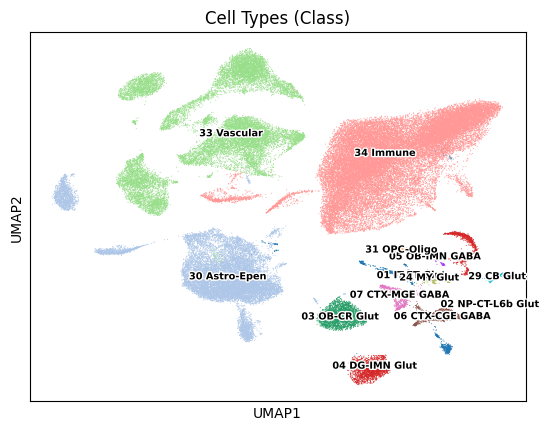

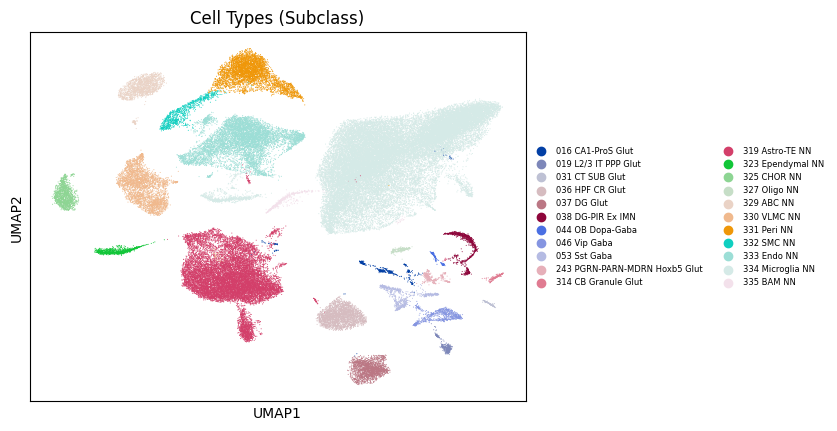

In [12]:
print("=== 2. PLOTTING ANNOTATED UMAPs ===")

# Plot Broad Cell Classes (Glutamate Neurons, Immune, Astro-Epen, Vascular, etc.)
sc.pl.umap(
    adata,
    color="cell_type_class",
    title="Cell Types (Class)",
    legend_loc="on data",
    legend_fontsize=7,
    legend_fontoutline=2,
    size=2,
    use_raw=False,
)

# Plot Detailed Subclasses (Microglia, Astro-TE, DG Glut, Oligo, Endo, etc.)
sc.pl.umap(
    adata,
    color="cell_type_subclass",
    title="Cell Types (Subclass)",
    ncols=1,
    legend_fontsize=6,
    size=2,
    use_raw=False,
)

In [13]:
adata.write("snRNA_fully_annotated.h5ad")
print("✅ Saved final annotated dataset: snRNA_fully_annotated.h5ad")

✅ Saved final annotated dataset: snRNA_fully_annotated.h5ad


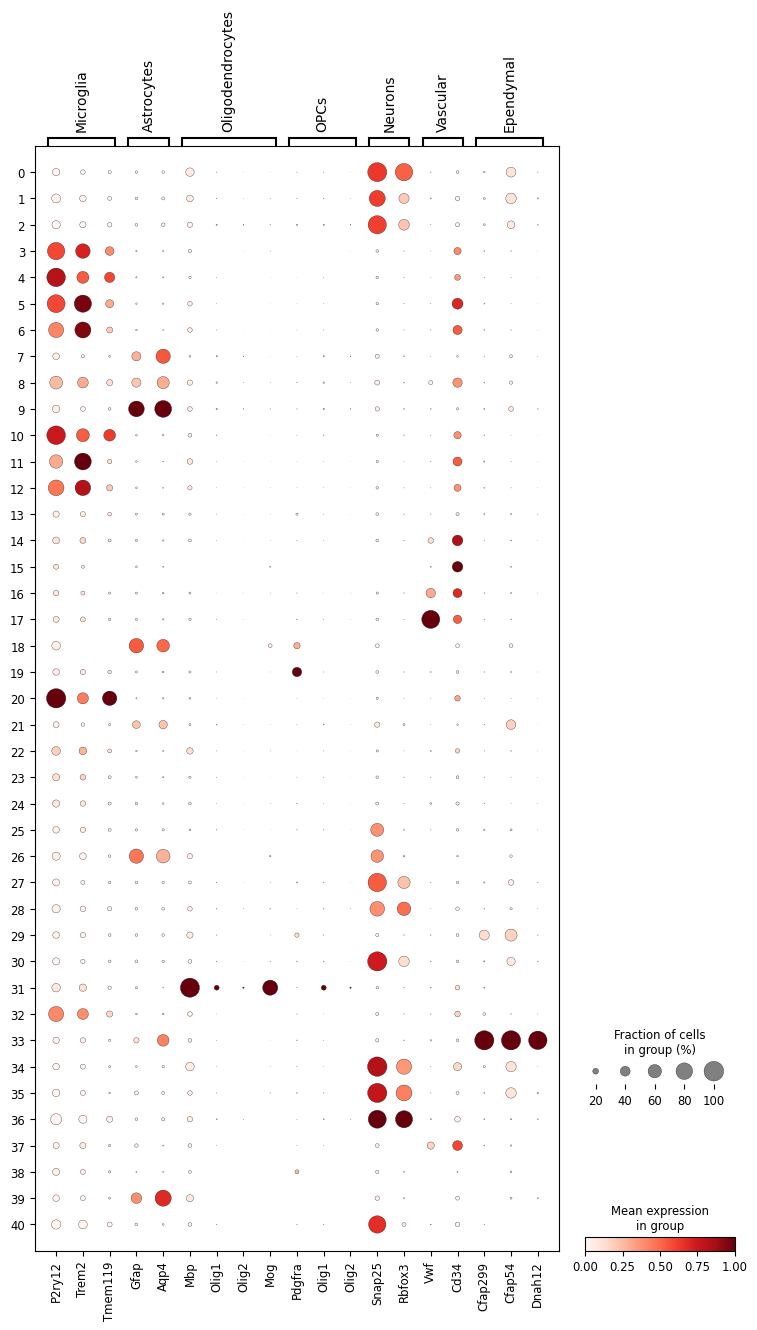

In [6]:
import scanpy as sc

# Load your saved AnnData object
adata = sc.read_h5ad("snRNA_fully_annotated.h5ad")

# 1. Define Canonical Mouse Brain Markers
brain_markers = {
    "Microglia": ["P2ry12", "Trem2", "Tmem119"],
    "Astrocytes": ["Gfap", "Aqp4"],
    "Oligodendrocytes": ["Mbp", "Olig1", "Olig2", "Mog"],
    "OPCs": ["Pdgfra", "Olig1", "Olig2"],
    "Neurons": ["Snap25", "Rbfox3"],
    "Vascular": ["Vwf", "Cd34"],
    "Ependymal": ["Cfap299", "Cfap54", "Dnah12"],
}

# 2. Run Dotplot on existing Leiden clusters
sc.pl.dotplot(adata, brain_markers, groupby="leiden", standard_scale="var")

categories: 0, 1, 2, etc.
var_group_labels: Microglia, Astrocytes, Oligodendrocytes, etc.


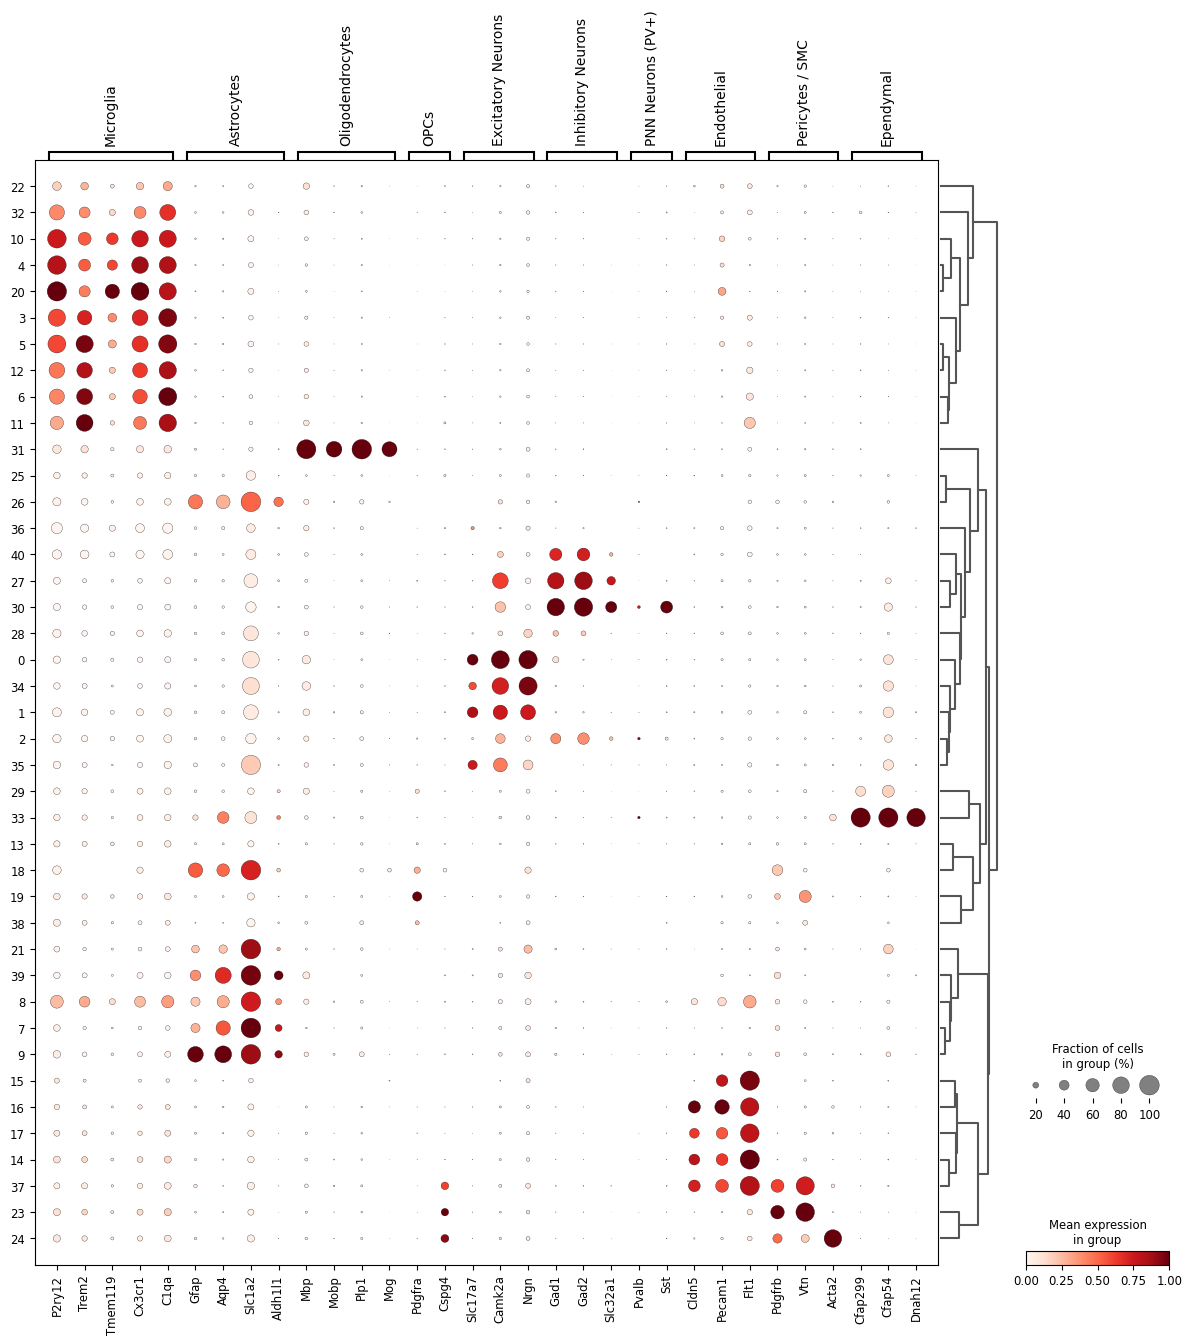

In [8]:
expanded_brain_markers = {
    # Microglia & Macrophages
    "Microglia": ["P2ry12", "Trem2", "Tmem119", "Cx3cr1", "C1qa"],
    # Astrocytes
    "Astrocytes": ["Gfap", "Aqp4", "Slc1a2", "Aldh1l1"],
    # Oligodendrocytes & OPCs
    "Oligodendrocytes": ["Mbp", "Mobp", "Plp1", "Mog"],
    "OPCs": ["Pdgfra", "Cspg4"],  # Cspg4 = NG2 (Key PNN/ECM regulator!)
    # Excitatory Neurons (Glutamatergic)
    "Excitatory Neurons": ["Slc17a7", "Camk2a", "Nrgn"],
    # Inhibitory Neurons (GABAergic & PNN-bearing)
    "Inhibitory Neurons": ["Gad1", "Gad2", "Slc32a1"],
    "PNN Neurons (PV+)": ["Pvalb", "Sst"],
    # Vascular, Pericytes & Mural
    "Endothelial": ["Cldn5", "Pecam1", "Flt1"],
    "Pericytes / SMC": ["Pdgfrb", "Vtn", "Acta2"],
    # Ependymal & Choroid
    "Ependymal": ["Cfap299", "Cfap54", "Dnah12"],
}

# Plot with the expanded gene set
sc.pl.dotplot(
    adata,
    expanded_brain_markers,
    groupby="leiden",
    standard_scale="var",
    dendrogram=True,
)